# 01 — Exploratory Data Analysis

This notebook explores the training data (`creditcard.csv`) and the 5 production drift batches.  
Goal: understand the baseline data distribution before any modelling or drift detection.

**Contents**
1. Load data
2. Dataset overview
3. Class imbalance
4. Feature distributions (Amount + V1–V28)
5. Correlation heatmap
6. Drift batch overview
7. Key observations

## 1. Load data

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats
import warnings
warnings.filterwarnings('ignore')

sns.set_theme(style='whitegrid', palette='muted')
plt.rcParams['figure.dpi'] = 100

In [2]:
import os
os.chdir(r'C:\Users\baxjo\OneDrive\Documenten\GitHub\datadrift-challenge')

train = pd.read_csv('data/creditcard.csv')

drift_batches = {
    'batch_1': pd.read_csv('data/drift_1.csv'),
    'batch_2': pd.read_csv('data/drift_2.csv'),
    'batch_3': pd.read_csv('data/drift_3.csv'),
    'batch_4': pd.read_csv('data/drift_4.csv'),
    'batch_5': pd.read_csv('data/drift_5.csv'),
}

print('Training data loaded:', train.shape)
for name, df in drift_batches.items():
    print(f'{name} loaded: {df.shape}')

Training data loaded: (284807, 31)
batch_1 loaded: (15000, 32)
batch_2 loaded: (15000, 32)
batch_3 loaded: (18000, 32)
batch_4 loaded: (15000, 32)
batch_5 loaded: (15000, 32)


## 2. Dataset overview

In [3]:
print('=== Training data ===' )
print(f'Rows: {len(train):,}')
print(f'Columns: {train.columns.tolist()}')
print(f'Missing values: {train.isnull().sum().sum()}')
train.describe().T

=== Training data ===
Rows: 284,807
Columns: ['Time', 'V1', 'V2', 'V3', 'V4', 'V5', 'V6', 'V7', 'V8', 'V9', 'V10', 'V11', 'V12', 'V13', 'V14', 'V15', 'V16', 'V17', 'V18', 'V19', 'V20', 'V21', 'V22', 'V23', 'V24', 'V25', 'V26', 'V27', 'V28', 'Amount', 'Class']
Missing values: 0


,count,mean,std,min,25%,50%,75%,max
Time,284807.0,9.481386e+04,47488.145955,0.000000,54201.500000,84692.000000,139320.500000,172792.000000
V1,284807.0,1.168375e-15,1.958696,-56.407510,-0.920373,0.018109,1.315642,2.454930
V2,284807.0,3.416908e-16,1.651309,-72.715728,-0.598550,0.065486,0.803724,22.057729
V3,284807.0,-1.379537e-15,1.516255,-48.325589,-0.890365,0.179846,1.027196,9.382558
V4,284807.0,2.074095e-15,1.415869,-5.683171,-0.848640,-0.019847,0.743341,16.875344
V5,284807.0,9.604066e-16,1.380247,-113.743307,-0.691597,-0.054336,0.611926,34.801666
V6,284807.0,1.487313e-15,1.332271,-26.160506,-0.768296,-0.274187,0.398565,73.301626
V7,284807.0,-5.556467e-16,1.237094,-43.557242,-0.554076,0.040103,0.570436,120.589494
V8,284807.0,1.213481e-16,1.194353,-73.216718,-0.208630,0.022358,0.327346,20.007208
V9,284807.0,-2.406331e-15,1.098632,-13.434066,-0.643098,-0.051429,0.597139,15.594995


In [4]:
# Summary table of all batches
summary = []
for name, df in drift_batches.items():
    summary.append({
        'batch': name,
        'rows': len(df),
        'fraud_count': df['Class'].sum(),
        'fraud_rate_%': round(df['Class'].mean() * 100, 4),
        'amount_mean': round(df['Amount'].mean(), 2),
        'amount_median': round(df['Amount'].median(), 2),
        'days': df['day'].nunique()
    })

# Add training row
summary.insert(0, {
    'batch': 'train',
    'rows': len(train),
    'fraud_count': train['Class'].sum(),
    'fraud_rate_%': round(train['Class'].mean() * 100, 4),
    'amount_mean': round(train['Amount'].mean(), 2),
    'amount_median': round(train['Amount'].median(), 2),
    'days': 'N/A'
})

pd.DataFrame(summary)

,batch,rows,fraud_count,fraud_rate_%,amount_mean,amount_median,days
0,train,284807,492,0.1727,88.35,22.00,N/A
1,batch_1,15000,29,0.1933,142.65,33.05,30
2,batch_2,15000,24,0.1600,639.87,363.19,30
3,batch_3,18000,94,0.5222,89.97,22.28,30
4,batch_4,15000,25,0.1667,89.45,22.43,30
5,batch_5,15000,300,2.0000,93.53,22.60,30


## 3. Class imbalance

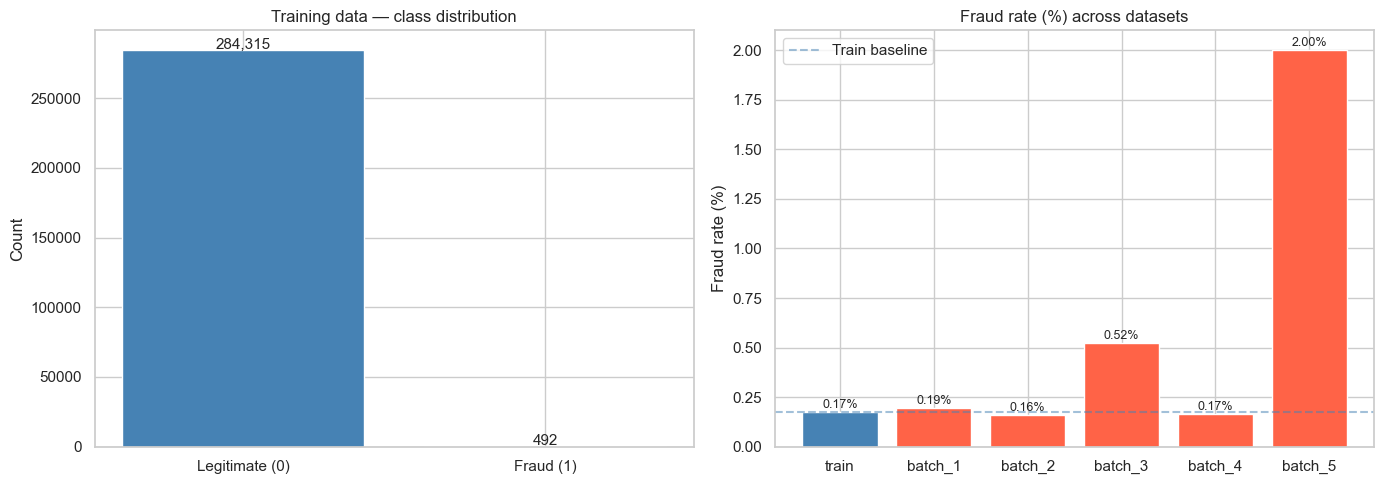

In [5]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Training class distribution
counts = train['Class'].value_counts()
axes[0].bar(['Legitimate (0)', 'Fraud (1)'], counts.values, color=['steelblue', 'tomato'])
axes[0].set_title('Training data — class distribution')
axes[0].set_ylabel('Count')
for i, v in enumerate(counts.values):
    axes[0].text(i, v + 1000, f'{v:,}', ha='center', fontsize=11)

# Fraud rate across all datasets
labels = ['train'] + list(drift_batches.keys())
fraud_rates = [train['Class'].mean() * 100] + [df['Class'].mean() * 100 for df in drift_batches.values()]
colors = ['steelblue'] + ['tomato'] * 5
axes[1].bar(labels, fraud_rates, color=colors)
axes[1].set_title('Fraud rate (%) across datasets')
axes[1].set_ylabel('Fraud rate (%)')
axes[1].axhline(fraud_rates[0], color='steelblue', linestyle='--', alpha=0.5, label='Train baseline')
axes[1].legend()
for i, v in enumerate(fraud_rates):
    axes[1].text(i, v + 0.02, f'{v:.2f}%', ha='center', fontsize=9)

plt.tight_layout()
plt.savefig('figures/eda_class_distribution.png', bbox_inches='tight')
plt.show()

## 4. Feature distributions

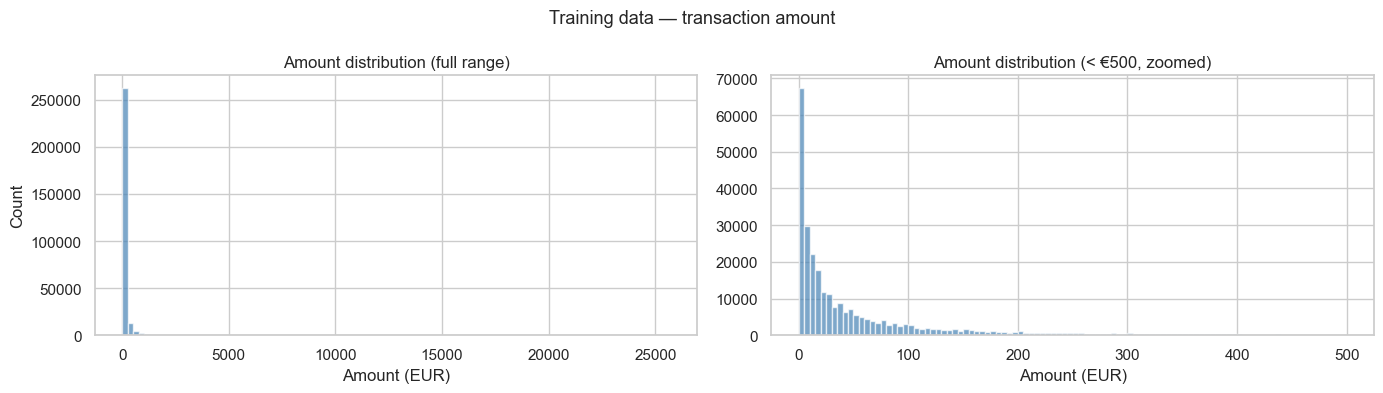

Amount stats:
count    284807.000000
mean         88.349619
std         250.120109
min           0.000000
25%           5.600000
50%          22.000000
75%          77.165000
max       25691.160000
Name: Amount, dtype: float64


In [6]:
# Amount distribution — training data
fig, axes = plt.subplots(1, 2, figsize=(14, 4))

axes[0].hist(train['Amount'], bins=100, color='steelblue', alpha=0.7)
axes[0].set_title('Amount distribution (full range)')
axes[0].set_xlabel('Amount (EUR)')
axes[0].set_ylabel('Count')

axes[1].hist(train[train['Amount'] < 500]['Amount'], bins=100, color='steelblue', alpha=0.7)
axes[1].set_title('Amount distribution (< €500, zoomed)')
axes[1].set_xlabel('Amount (EUR)')

plt.suptitle('Training data — transaction amount', fontsize=13)
plt.tight_layout()
plt.savefig('figures/eda_amount_dist.png', bbox_inches='tight')
plt.show()

print(f"Amount stats:\n{train['Amount'].describe()}")

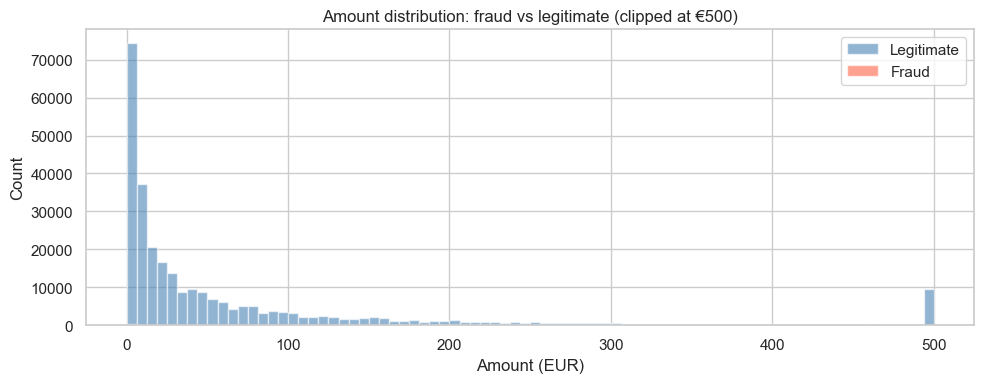

In [7]:
# Amount: fraud vs legitimate comparison
fig, ax = plt.subplots(figsize=(10, 4))

train[train['Class'] == 0]['Amount'].clip(upper=500).hist(
    bins=80, alpha=0.6, label='Legitimate', color='steelblue', ax=ax)
train[train['Class'] == 1]['Amount'].clip(upper=500).hist(
    bins=80, alpha=0.6, label='Fraud', color='tomato', ax=ax)

ax.set_title('Amount distribution: fraud vs legitimate (clipped at €500)')
ax.set_xlabel('Amount (EUR)')
ax.set_ylabel('Count')
ax.legend()
plt.tight_layout()
plt.show()

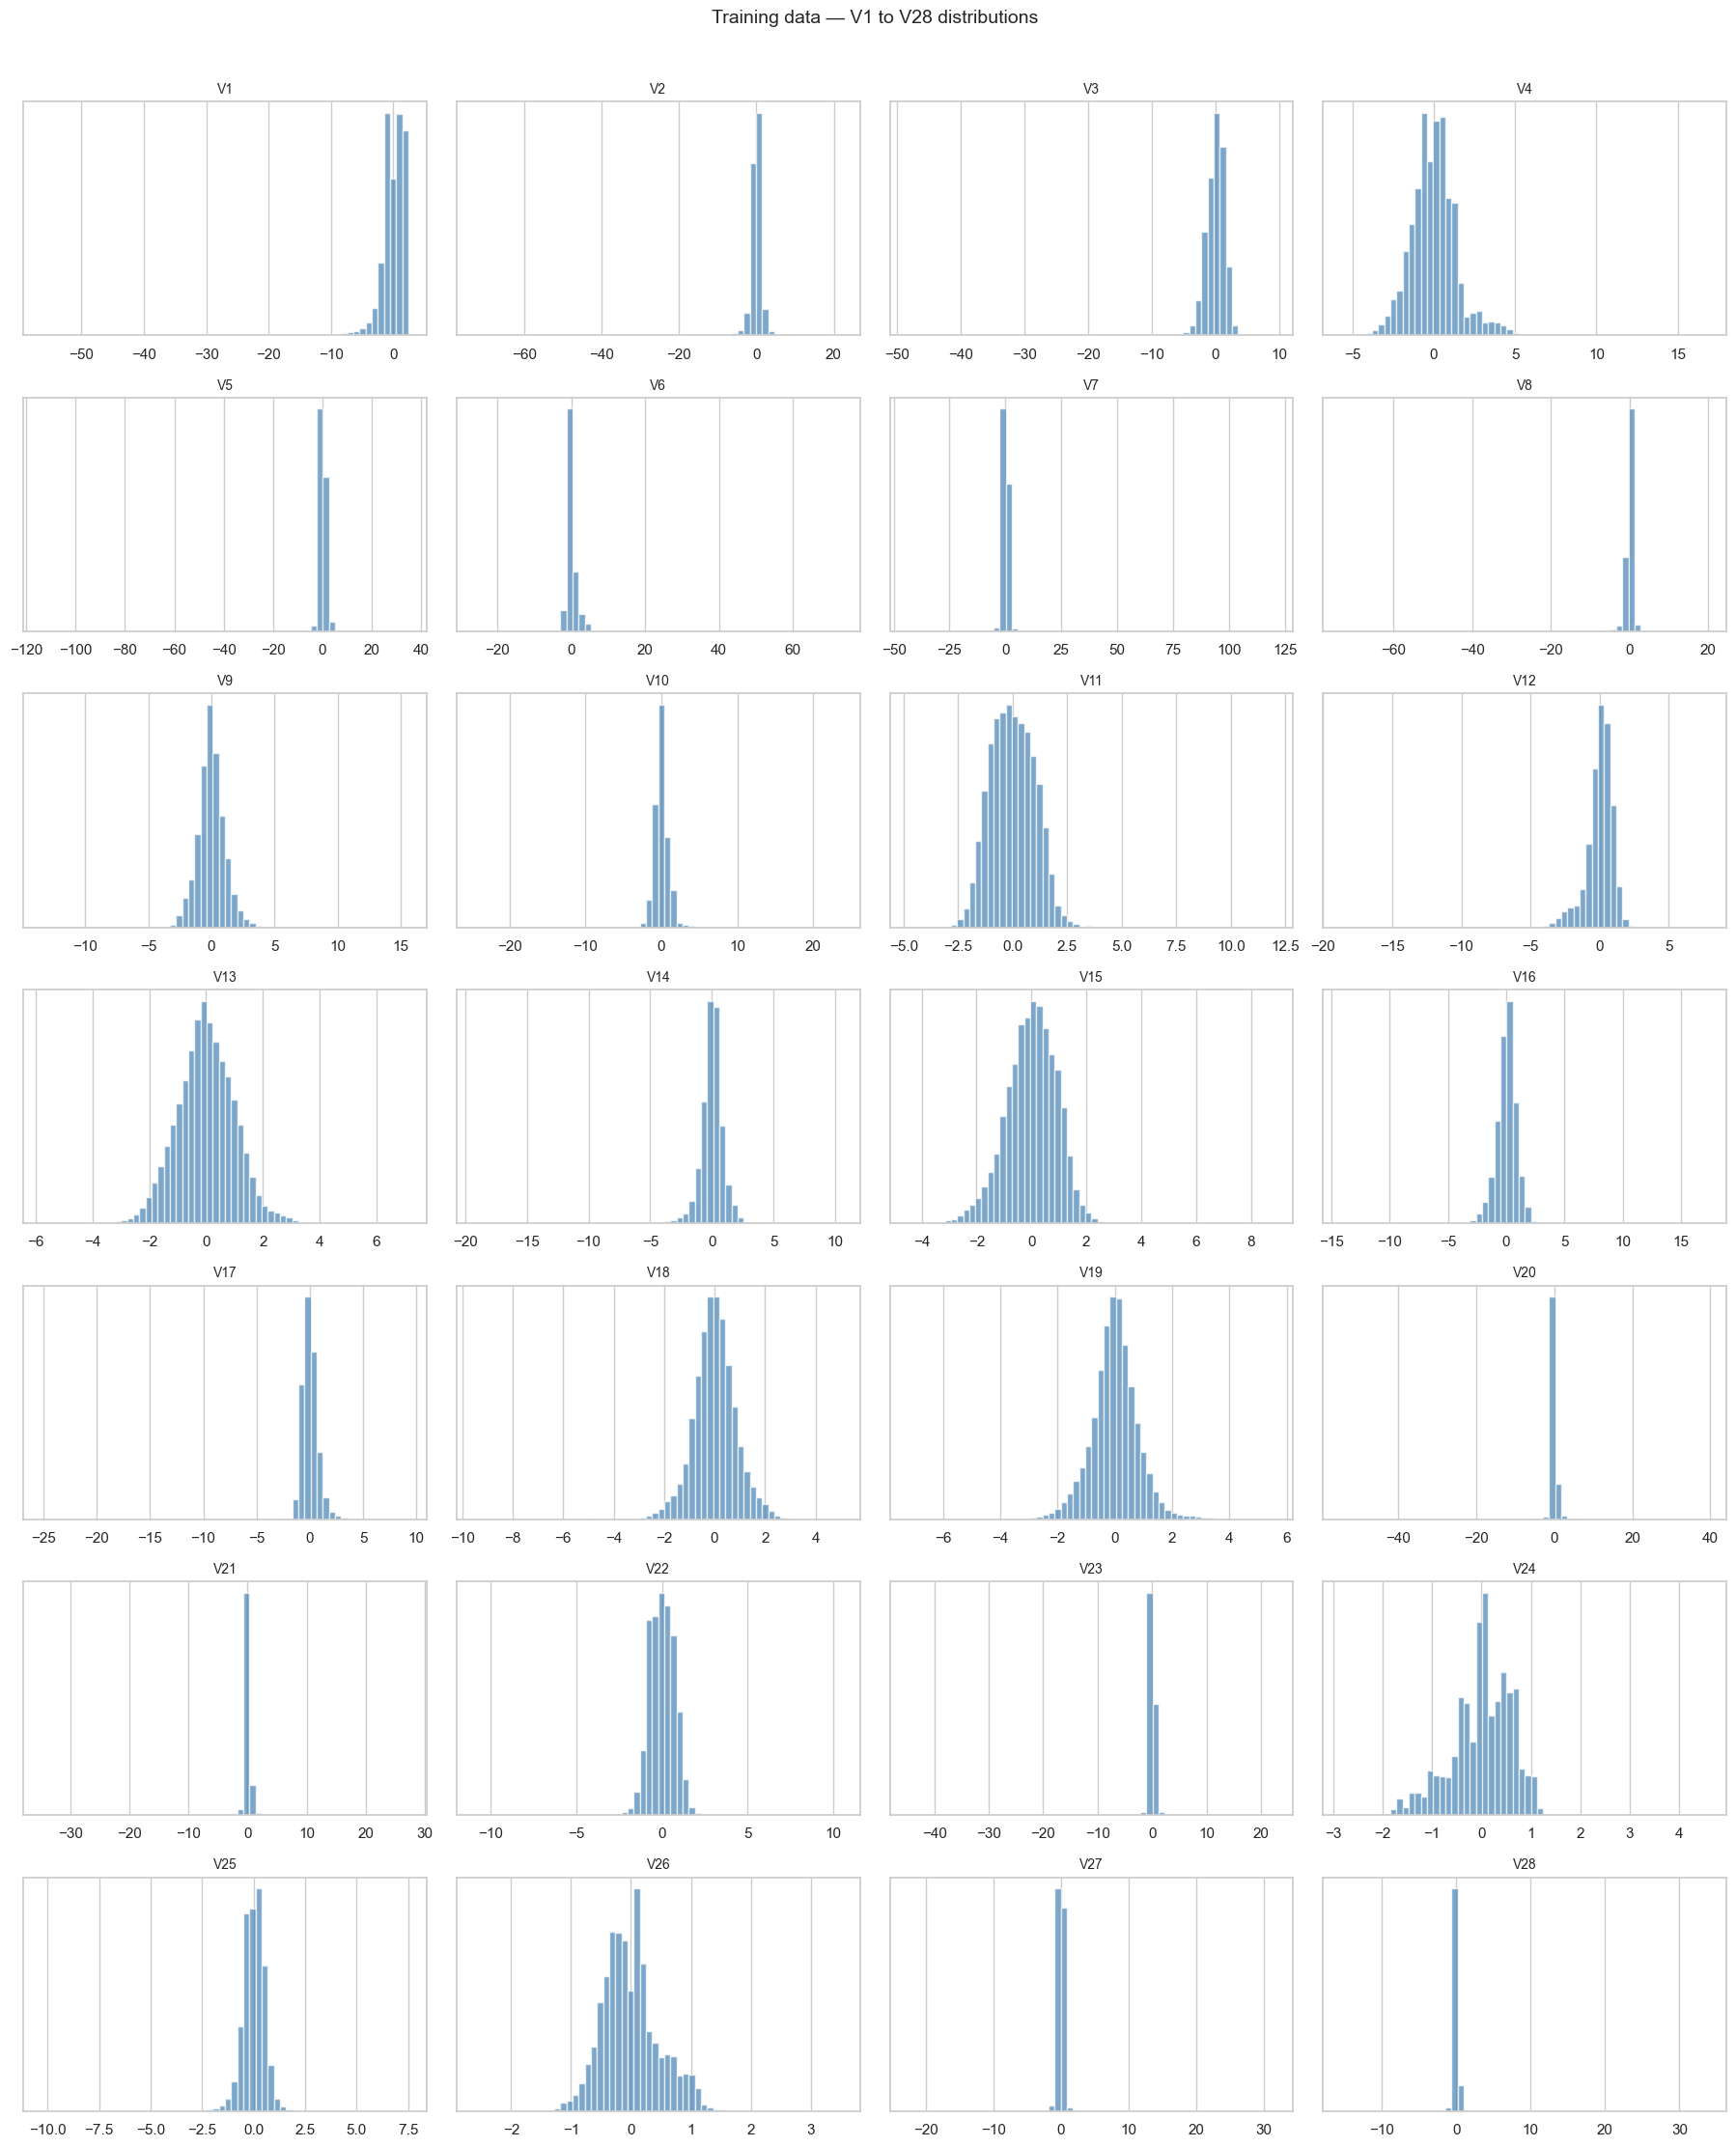

In [8]:
# V features — distribution overview (training data)
v_features = [f'V{i}' for i in range(1, 29)]

fig, axes = plt.subplots(7, 4, figsize=(18, 22))
axes = axes.flatten()

for i, feat in enumerate(v_features):
    axes[i].hist(train[feat], bins=60, color='steelblue', alpha=0.7)
    axes[i].set_title(feat, fontsize=10)
    axes[i].set_yticks([])

plt.suptitle('Training data — V1 to V28 distributions', fontsize=14, y=1.01)
plt.tight_layout()
plt.savefig('figures/eda_v_features.png', bbox_inches='tight')
plt.show()

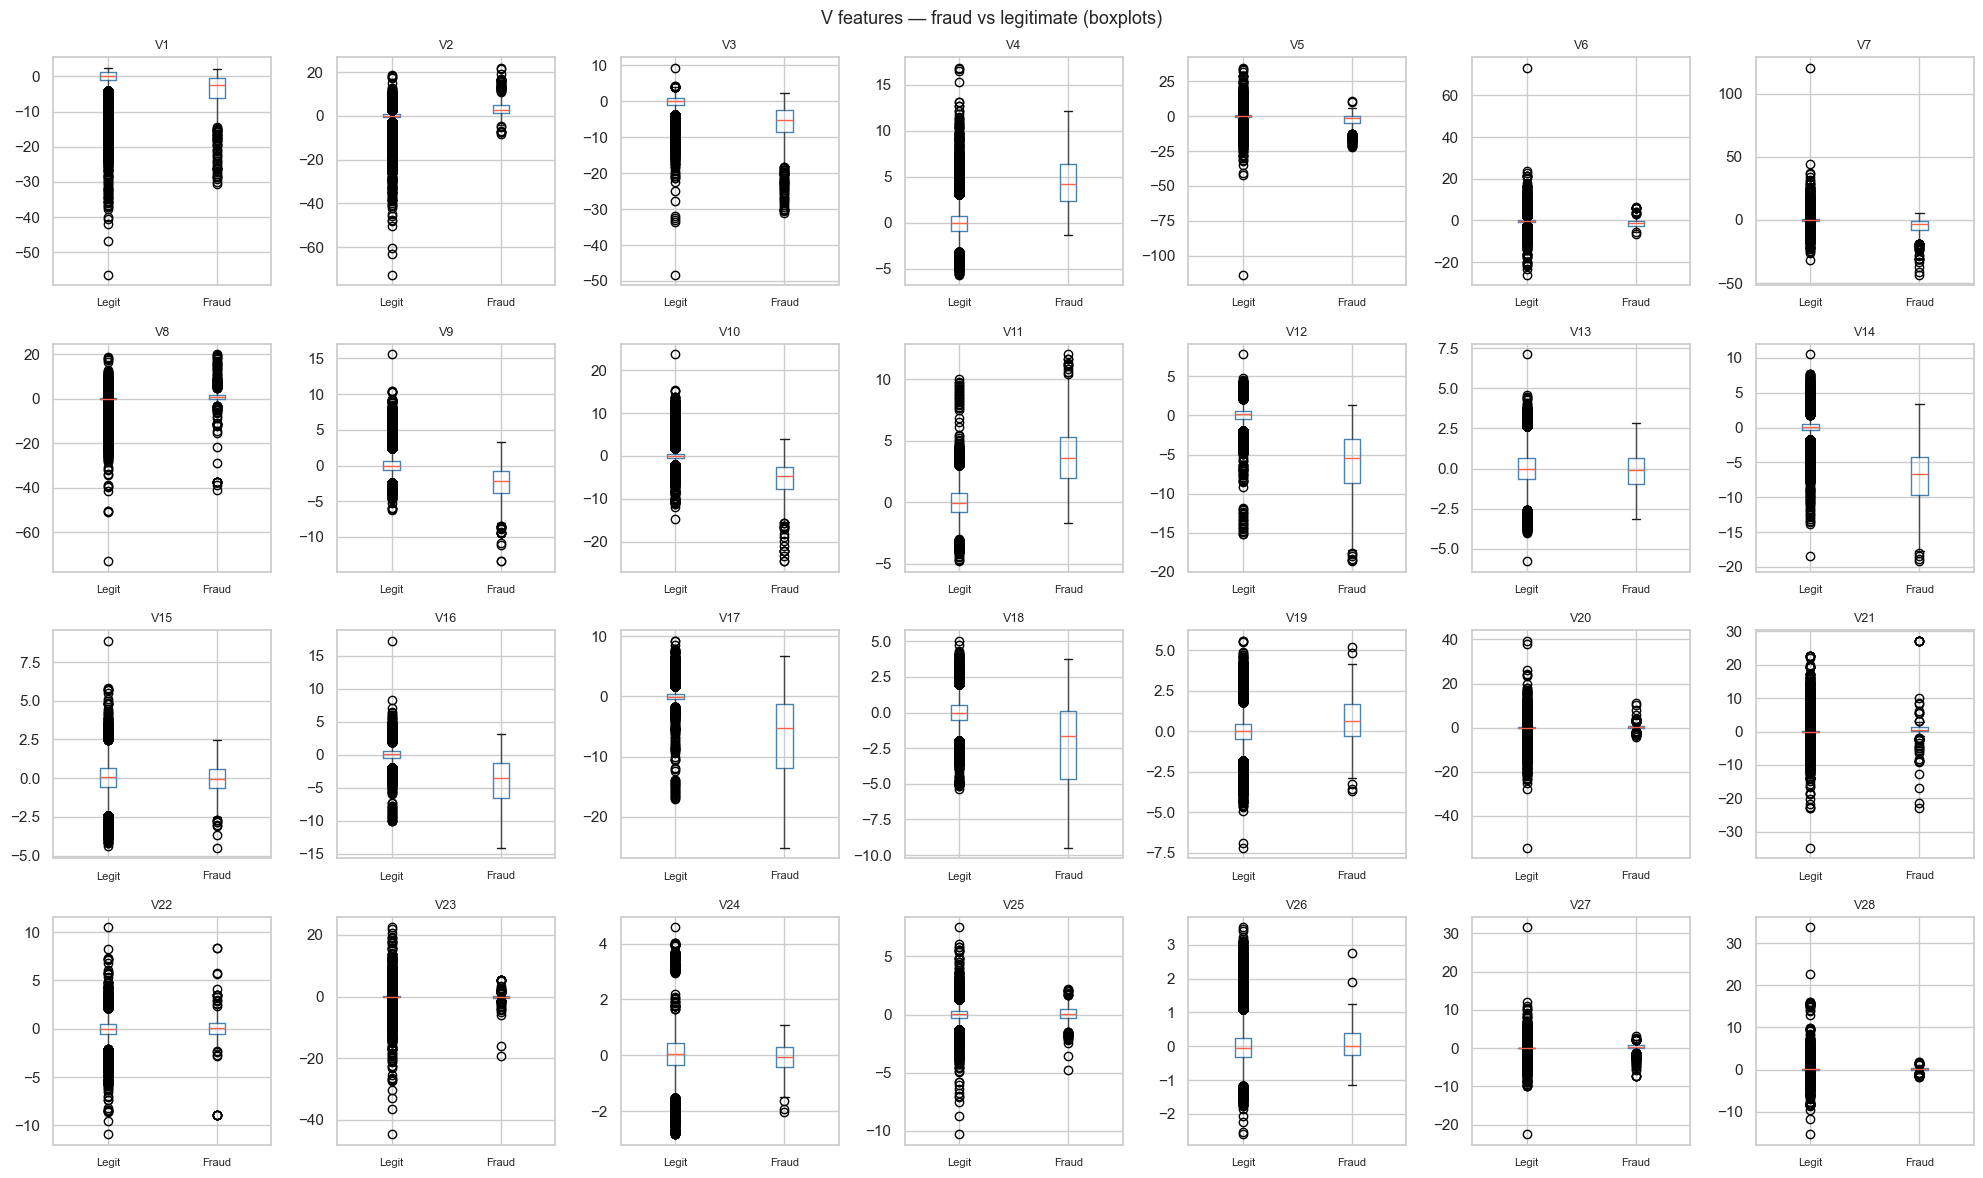

In [9]:
# V features: fraud vs legitimate (boxplots for top discriminating features)
fig, axes = plt.subplots(4, 7, figsize=(20, 12))
axes = axes.flatten()

for i, feat in enumerate(v_features):
    train.boxplot(column=feat, by='Class', ax=axes[i], 
                  boxprops=dict(color='steelblue'),
                  medianprops=dict(color='tomato'))
    axes[i].set_title(feat, fontsize=9)
    axes[i].set_xlabel('')
    axes[i].set_xticklabels(['Legit', 'Fraud'], fontsize=8)

plt.suptitle('V features — fraud vs legitimate (boxplots)', fontsize=13)
plt.tight_layout()
plt.savefig('figures/eda_boxplots.png', bbox_inches='tight')
plt.show()

## 5. Correlation heatmap

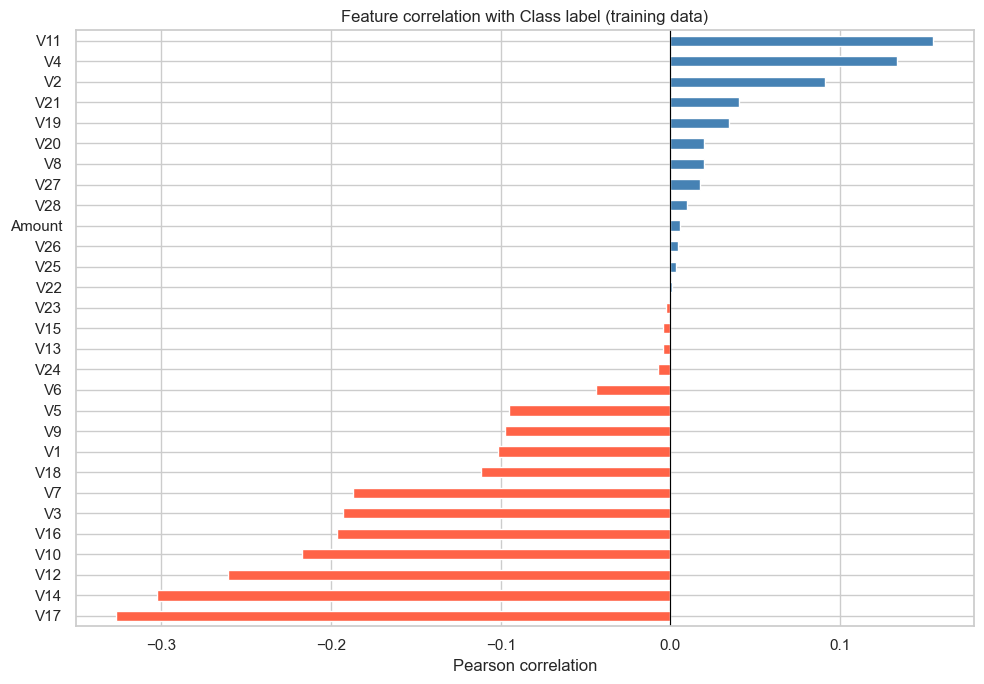


Top 5 positive correlations with fraud:
V19    0.034783
V21    0.040413
V2     0.091289
V4     0.133447
V11    0.154876
Name: Class, dtype: float64

Top 5 negative correlations with fraud:
V17   -0.326481
V14   -0.302544
V12   -0.260593
V10   -0.216883
V16   -0.196539
Name: Class, dtype: float64


In [10]:
# Correlation with Class label
correlations = train[v_features + ['Amount', 'Class']].corr()['Class'].drop('Class').sort_values()

fig, ax = plt.subplots(figsize=(10, 7))
colors = ['tomato' if v < 0 else 'steelblue' for v in correlations.values]
correlations.plot(kind='barh', ax=ax, color=colors)
ax.axvline(0, color='black', linewidth=0.8)
ax.set_title('Feature correlation with Class label (training data)')
ax.set_xlabel('Pearson correlation')
plt.tight_layout()
plt.savefig('figures/eda_correlations.png', bbox_inches='tight')
plt.show()

print('\nTop 5 positive correlations with fraud:')
print(correlations.tail(5))
print('\nTop 5 negative correlations with fraud:')
print(correlations.head(5))

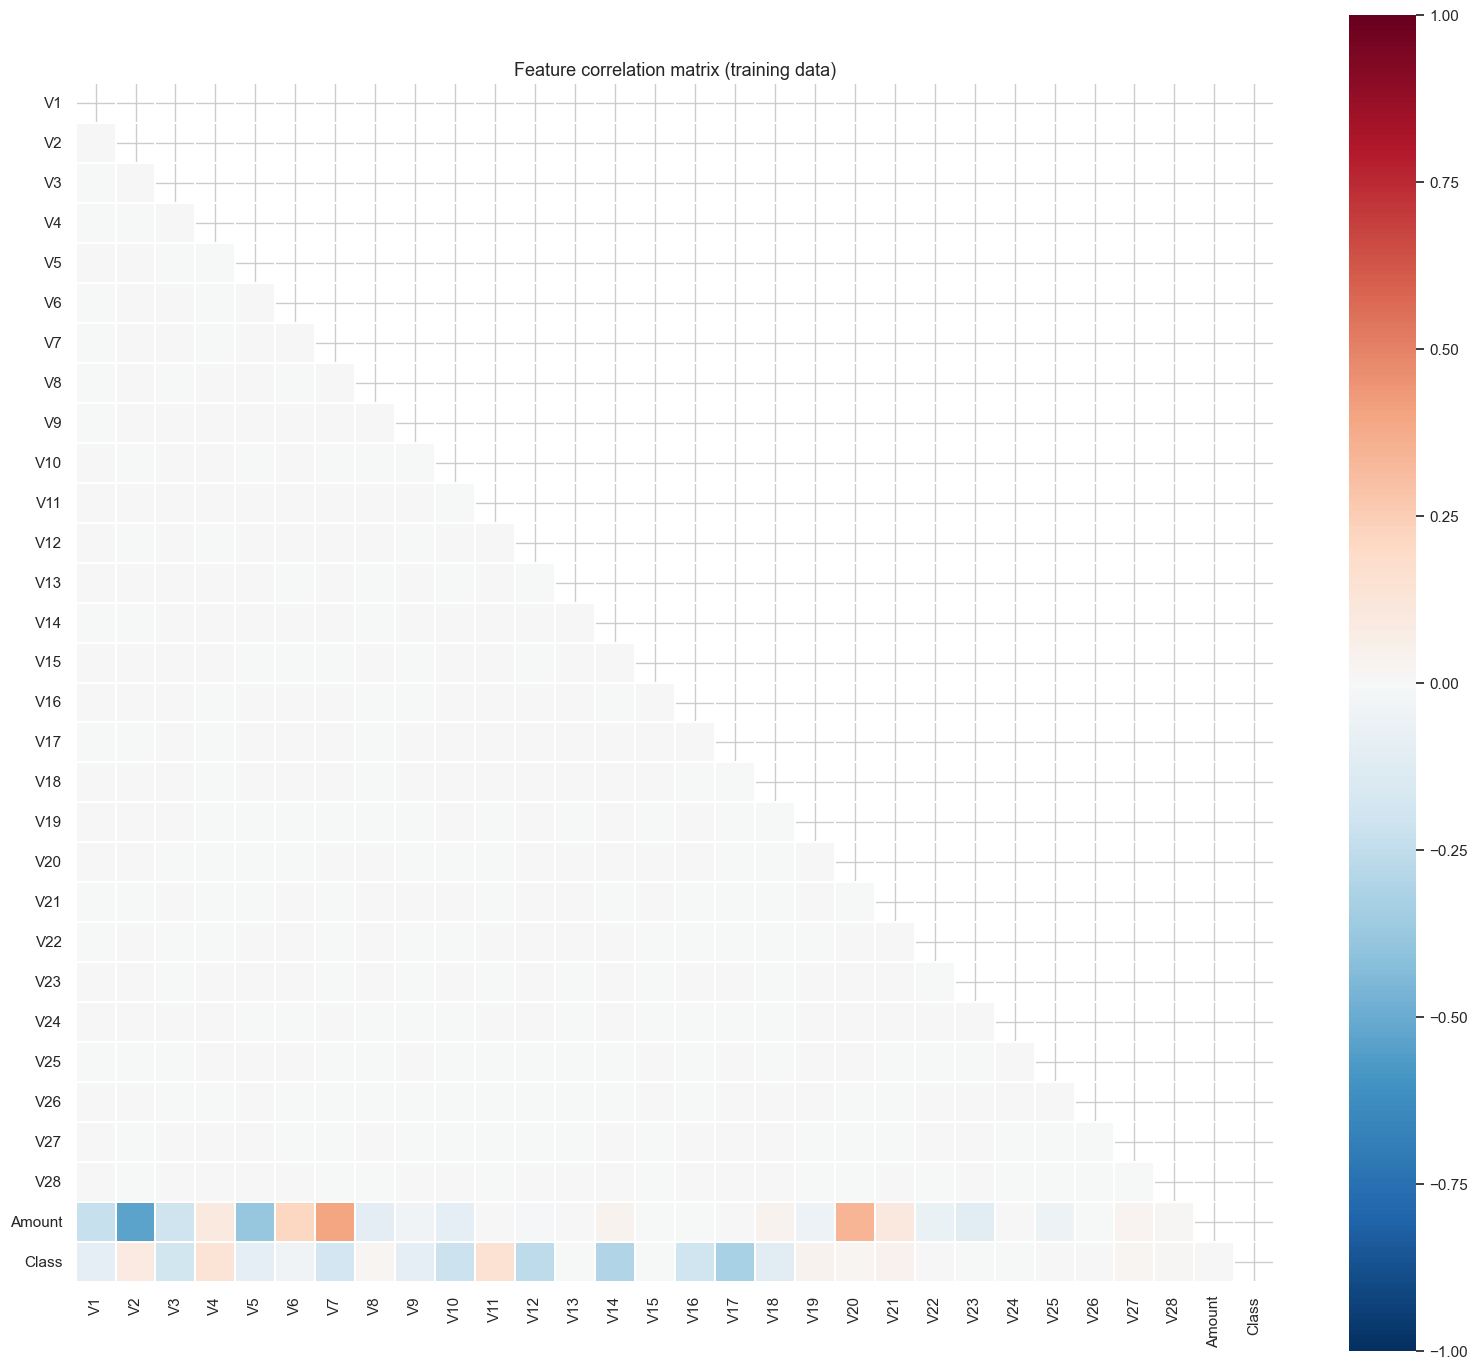

In [11]:
# Full correlation heatmap (V features only)
fig, ax = plt.subplots(figsize=(16, 14))
corr_matrix = train[v_features + ['Amount', 'Class']].corr()
mask = np.triu(np.ones_like(corr_matrix, dtype=bool))
sns.heatmap(corr_matrix, mask=mask, cmap='RdBu_r', center=0,
            vmin=-1, vmax=1, ax=ax, linewidths=0.3,
            annot=False, square=True)
ax.set_title('Feature correlation matrix (training data)', fontsize=13)
plt.tight_layout()
plt.savefig('figures/eda_heatmap.png', bbox_inches='tight')
plt.show()

## 6. Drift batch overview

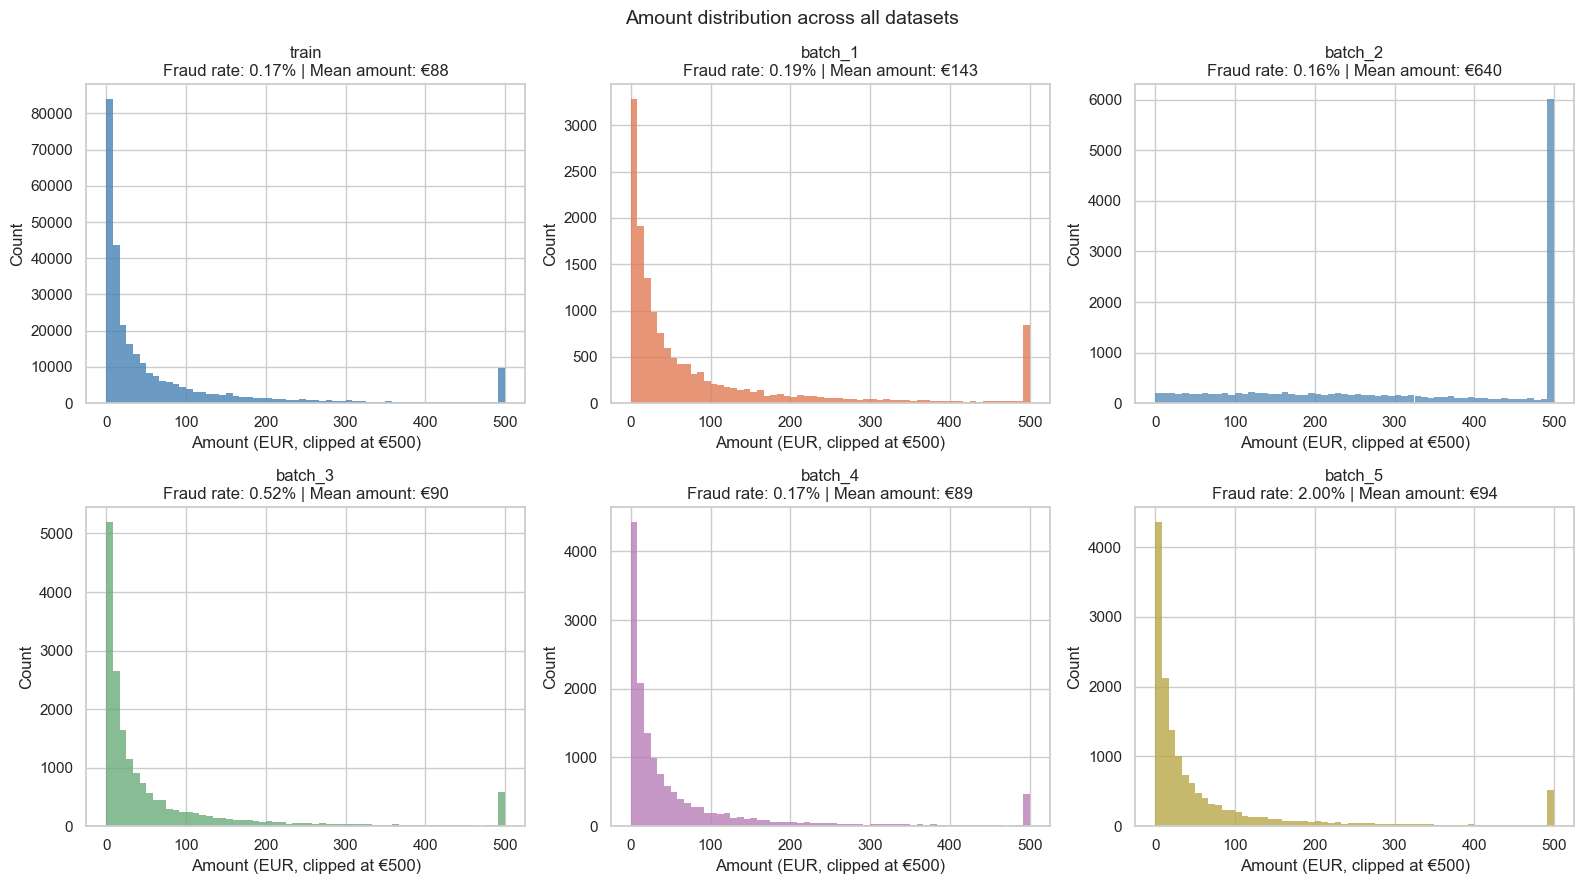

In [12]:
# Amount distribution: train vs all drift batches
fig, axes = plt.subplots(2, 3, figsize=(16, 9))
axes = axes.flatten()

all_data = [('train', train)] + list(drift_batches.items())
colors_map = ['steelblue', '#e07b54', '#5b8db8', '#6aab7a', '#b87eb8', '#b8a84a']

for i, (name, df) in enumerate(all_data):
    axes[i].hist(df['Amount'].clip(upper=500), bins=60, 
                 color=colors_map[i], alpha=0.8, edgecolor='none')
    fraud_rate = df['Class'].mean() * 100
    mean_amt = df['Amount'].mean()
    axes[i].set_title(f'{name}\nFraud rate: {fraud_rate:.2f}% | Mean amount: €{mean_amt:.0f}')
    axes[i].set_xlabel('Amount (EUR, clipped at €500)')
    axes[i].set_ylabel('Count')

plt.suptitle('Amount distribution across all datasets', fontsize=14)
plt.tight_layout()
plt.savefig('figures/eda_amount_batches.png', bbox_inches='tight')
plt.show()

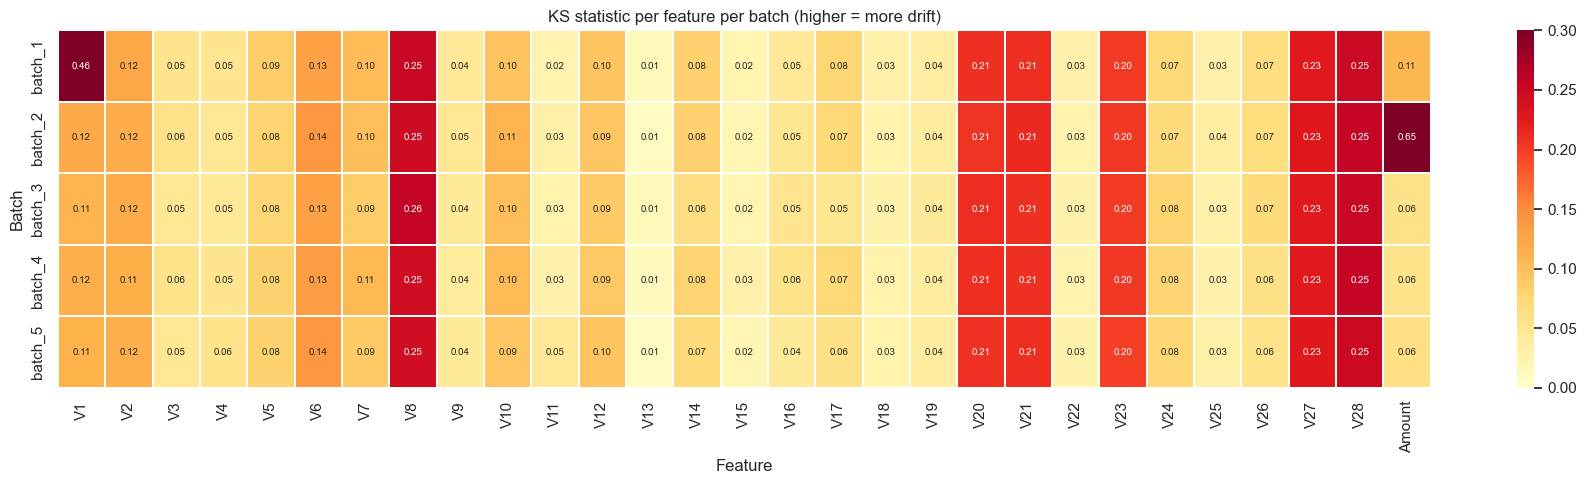


Most drifted features per batch:
  batch_1: {'V1': 0.4556, 'V8': 0.2507, 'V28': 0.2488}
  batch_2: {'Amount': 0.652, 'V28': 0.2538, 'V8': 0.2472}
  batch_3: {'V8': 0.2565, 'V28': 0.2498, 'V27': 0.2258}
  batch_4: {'V28': 0.2534, 'V8': 0.2456, 'V27': 0.2256}
  batch_5: {'V28': 0.2483, 'V8': 0.2451, 'V27': 0.228}


In [13]:
# Quick KS test: which features drift most in each batch?
from scipy.stats import ks_2samp

features_to_test = v_features + ['Amount']
ks_results = {}

for name, df in drift_batches.items():
    ks_results[name] = {}
    for feat in features_to_test:
        stat, p = ks_2samp(train[feat], df[feat])
        ks_results[name][feat] = round(stat, 4)

ks_df = pd.DataFrame(ks_results).T

# Heatmap of KS statistics
fig, ax = plt.subplots(figsize=(18, 5))
sns.heatmap(ks_df, cmap='YlOrRd', ax=ax, linewidths=0.3,
            annot=True, fmt='.2f', annot_kws={'size': 7},
            vmin=0, vmax=0.3)
ax.set_title('KS statistic per feature per batch (higher = more drift)', fontsize=12)
ax.set_xlabel('Feature')
ax.set_ylabel('Batch')
plt.tight_layout()
plt.savefig('figures/eda_ks_heatmap.png', bbox_inches='tight')
plt.show()

print('\nMost drifted features per batch:')
for name in ks_df.index:
    top3 = ks_df.loc[name].nlargest(3)
    print(f'  {name}: {top3.to_dict()}')

## 7. Key observations

Fill in after running the notebook:

- **Class imbalance**: Training data has a fraud rate of ~0.17%. This is severely imbalanced — standard accuracy is meaningless. Use F1 / AUC-ROC.
- **Amount**: Right-skewed distribution. Most transactions are under €100. Batch 2 shows a much higher mean amount (~€640), indicating potential covariate drift.
- **Fraud rate drift**: Batch 5 has a 2.0% fraud rate — ~12x higher than training. Batch 3 also elevated at 0.52%. These are likely the most challenging batches.
- **Feature drift**: V28, V8, V27, V21, V20, V23 show the highest KS statistics in batch 5. These will be key features to monitor.
- **Correlations**: V17, V14, V12, V10 show the strongest negative correlation with fraud. V11, V4, V2 show positive correlation.

> Detailed drift analysis continues in `03_drift_detection.ipynb`.